## 1. Data Loading

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
# Data not included in repo — see data/README.md for sourcing instructions
cbb_filepath = 'data/d1_teams_2008_2026.csv'
cbb_data = pd.read_csv(cbb_filepath)
cbb_data.head()

AdjEM (Adjusted Efficiency Margin) measures a team's net points per 100 possessions adjusted for opponent strength. Continuity measures the percentage of minutes returning from the prior season

## 2. Continuity Trend

In [127]:
cbb_filtered = cbb_data.dropna()
avg_cont_by_year = cbb_filtered.groupby(cbb_filtered.Season).Continuity.mean()


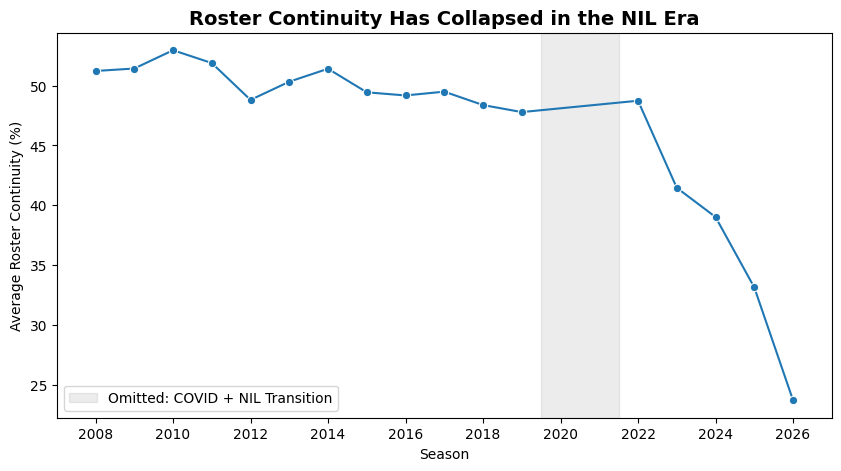

In [128]:
plt.figure(figsize=(10,5))

sns.lineplot(data=avg_cont_by_year, marker='o')


plt.title('Roster Continuity Has Collapsed in the NIL Era', fontsize=14, fontweight='bold')
plt.ylabel('Average Roster Continuity (%)')
plt.xlabel('Season')
plt.xticks(range(2008,2027,2))
plt.xlim(2007,2027)
plt.axvspan(2019.5, 2021.5, color='gray', alpha=0.15, label='Omitted: COVID + NIL Transition')
plt.legend()

2020 and 2021 are excluded from both groups. The 2020 season was shortened by COVID, and 2021 was a transition year during which NIL rules and the transfer portal were still being established. Including either would contaminate the pre/post comparison.

## 3. Overall Regression

In [129]:
pre_nil_data = cbb_filtered[cbb_filtered.Season <= 2019]
post_nil_data = cbb_filtered[cbb_filtered.Season >= 2022]

In [136]:
pre_continuity_arr = pre_nil_data.Continuity.values.reshape(-1,1)
post_continuity_arr = post_nil_data.Continuity.values.reshape(-1,1)
pre_adjem_arr = pre_nil_data.AdjEM.values
post_adjem_arr = post_nil_data.AdjEM.values


model_pre = LinearRegression().fit(pre_continuity_arr, pre_adjem_arr)
model_post = LinearRegression().fit(post_continuity_arr, post_adjem_arr)

print(f"Pre-NIL slope:  {model_pre.coef_[0]:.3f}")
print(f"Post-NIL slope: {model_post.coef_[0]:.3f}")

Pre-NIL slope:  0.237
Post-NIL slope: 0.099


Continuity was never the dominant driver of performance — pre-NIL, it explained roughly 9% of variance in AdjEM. But even that modest signal has largely disappeared.

Text(0.05, 0.95, '$r^2 = 0.023$')

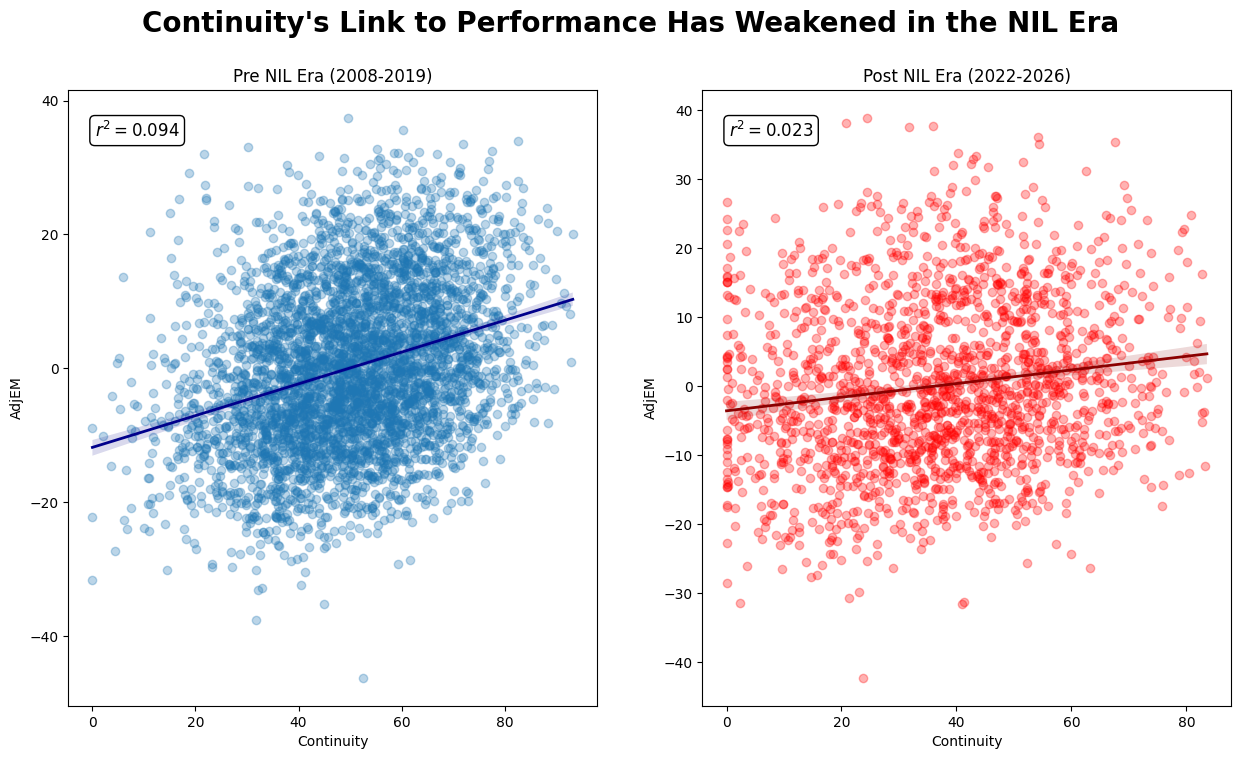

In [131]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

r2_pre = model_pre.score(pre_continuity_arr, pre_adjem_arr)
r2_post = model_post.score(post_continuity_arr, post_adjem_arr)
textstr_pre = f'$r^2 = {r2_pre:.3f}$'
textstr_post = f'$r^2 = {r2_post:.3f}$'

props = dict(boxstyle='round', facecolor='white', alpha=1)

sns.regplot(
    x='Continuity', 
    y='AdjEM', 
    data=pre_nil_data, 
    ax=ax1, 
    scatter_kws={'alpha':0.3}, 
    line_kws={'alpha':1.0, 'lw':2, 'color':'darkblue'})

sns.regplot(
    x='Continuity', 
    y='AdjEM', 
    data=post_nil_data, 
    ax=ax2, 
    color='red',
    scatter_kws={'alpha':0.3},
    line_kws={'alpha':1.0, 'lw':2, 'color':'darkred'})

plt.suptitle("Continuity's Link to Performance Has Weakened in the NIL Era", fontsize=20, fontweight='bold')
ax1.set_title("Pre NIL Era (2008-2019)")
ax2.set_title("Post NIL Era (2022-2026)")
ax1.text(0.05, 0.95, textstr_pre, transform=ax1.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax2.text(0.05, 0.95, textstr_post, transform=ax2.transAxes, fontsize=12, verticalalignment='top', bbox=props)

The regression slope fell from 0.24 to 0.10 — meaning the performance advantage predicted by a 20 pct-pt continuity edge dropped from ~4.7 AdjEM points to ~2.0. That gap was once the difference between a tournament team and a bubble team.

## 4. Tier Analysis

In [132]:
# Splitting teams based on average AdjEM over era
top_teams_pre = pre_nil_data.groupby('Team Name').AdjEM.mean().nlargest(100).index
top_teams_post = post_nil_data.groupby('Team Name').AdjEM.mean().nlargest(100).index

# Season Level Splitting
top_pre = pre_nil_data[pre_nil_data['Team Name'].isin(top_teams_pre)]
bottom_pre = pre_nil_data[~pre_nil_data['Team Name'].isin(top_teams_pre)]
top_post = post_nil_data[post_nil_data['Team Name'].isin(top_teams_post)]
bottom_post = post_nil_data[~post_nil_data['Team Name'].isin(top_teams_post)]


In [133]:
model_tpre = LinearRegression().fit(top_pre.Continuity.values.reshape(-1,1), top_pre.AdjEM.values)
model_tpost = LinearRegression().fit(top_post.Continuity.values.reshape(-1,1), top_post.AdjEM.values)
model_bpre = LinearRegression().fit(bottom_pre.Continuity.values.reshape(-1,1), bottom_pre.AdjEM.values)
model_bpost = LinearRegression().fit(bottom_post.Continuity.values.reshape(-1,1), bottom_post.AdjEM.values)

r2_tpre= model_tpre.score(top_pre.Continuity.values.reshape(-1,1), top_pre.AdjEM.values)
r2_tpost = model_tpost.score(top_post.Continuity.values.reshape(-1,1), top_post.AdjEM.values)

r2_bpre= model_bpre.score(bottom_pre.Continuity.values.reshape(-1,1), bottom_pre.AdjEM.values)
r2_bpost = model_bpost.score(bottom_post.Continuity.values.reshape(-1,1), bottom_post.AdjEM.values)

textstr_tpre = f'$r^2 = {r2_tpre:.3f}$'
textstr_tpost = f'$r^2 = {r2_tpost:.3f}$'
textstr_bpre = f'$r^2 = {r2_bpre:.3f}$'
textstr_bpost = f'$r^2 = {r2_bpost:.3f}$'

Text(0.5, 0.98, 'Splitting by Tier Reveals a Hidden Divide')

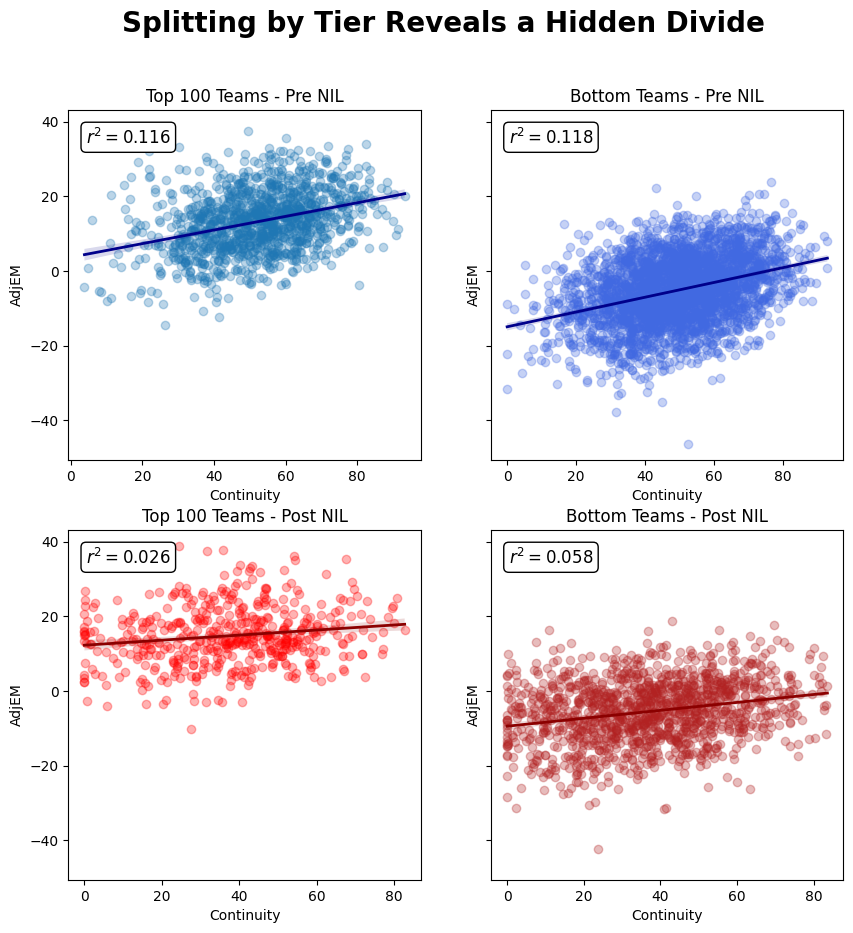

In [139]:
fig, ax = plt.subplots(2, 2, figsize=(10,10), sharey=True)

sns.regplot(
    x='Continuity',
    y='AdjEM',
    data=top_pre,
    ax=ax[0,0],
    scatter_kws={'alpha':0.3}, 
    line_kws={'alpha':1.0, 'lw':2, 'color':'darkblue'}
)

sns.regplot(
    x='Continuity',
    y='AdjEM',
    data=bottom_pre,
    ax=ax[0,1],
    scatter_kws={'alpha':0.3, 'color':'royalblue'},
    line_kws={'alpha':1.0, 'lw':2, 'color':'darkblue'}
)

sns.regplot(
    x='Continuity',
    y='AdjEM',
    data=top_post,
    ax=ax[1,0],
    scatter_kws={'alpha':0.3, 'color':'red'},
    line_kws={'alpha':1.0, 'lw':2, 'color':'darkred'}
)

sns.regplot(
    x='Continuity',
    y='AdjEM',
    data=bottom_post,
    ax=ax[1,1],
    scatter_kws={'alpha':0.3, 'color':'firebrick'},
    line_kws={'alpha':1.0, 'lw':2, 'color':'darkred'}
)

ax[0,0].text(0.05, 0.95, textstr_tpre, transform=ax[0,0].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[1,0].text(0.05, 0.95, textstr_tpost, transform=ax[1,0].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[0,1].text(0.05, 0.95, textstr_bpre, transform=ax[0,1].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[1,1].text(0.05, 0.95, textstr_bpost, transform=ax[1,1].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax[0,0].set_title('Top 100 Teams - Pre NIL')
ax[1,0].set_title('Top 100 Teams - Post NIL')
ax[0,1].set_title('Bottom Teams - Pre NIL')
ax[1,1].set_title('Bottom Teams - Post NIL')
plt.suptitle("Splitting by Tier Reveals a Hidden Divide", fontsize=20, fontweight='bold')


Text(0.5, 1.0, 'The Decoupling Hit Every Tier - But Top Programs Lost the Most')

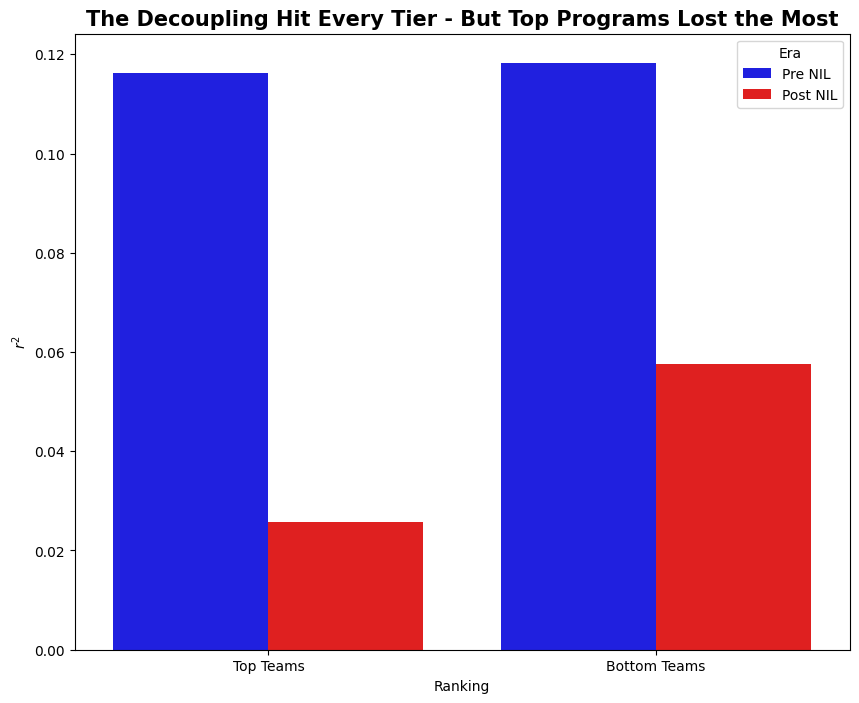

In [135]:
data = {
    'Ranking': ['Top Teams', 'Top Teams', 'Bottom Teams', 'Bottom Teams'],
    'Era': ['Pre NIL', 'Post NIL', 'Pre NIL', 'Post NIL'],
    '$r^2$': [r2_tpre, r2_tpost, r2_bpre, r2_bpost]
}
df = pd.DataFrame(data)

my_colors = {'Pre NIL': 'blue', 'Post NIL': 'red'}

plt.figure(figsize=(10,8))

sns.barplot(
    data=df, 
    x='Ranking', 
    y='$r^2$', 
    hue='Era',
    palette=my_colors)
plt.title('The Decoupling Hit Every Tier - But Top Programs Lost the Most', fontweight='bold', fontsize=15)



## 5. Conclusion

The NIL era and transfer portal have fundamentally changed the relationship between roster continuity and on-court performance in Division I men's basketball.

Three findings stand out:

1. **Continuity has collapsed.** Average roster continuity fell from roughly 51% pre-NIL to 24% by 2026.

2. **The predictive signal nearly vanished.** Continuity explained about 9% of AdjEM variance before NIL which is a modest but real relationship. Post-NIL, that figure dropped to 2.3%, and the regression slope fell from 0.24 to 0.10. A 20 pct-pt continuity edge once predicted a ~4.7 AdjEM point performance gap; today it predicts roughly 2.0 points.

3. **No tier was spared, but top programs lost the most.** Elite programs saw their continuity-to-performance R² drop 78% (0.116 → 0.026); bottom programs dropped 51% (0.118 → 0.058). The transfer portal may be allowing top programs to reload with high-impact transfers regardless of how many players return, weakening the traditional advantage of a returning core.

**Limitations:** This analysis uses a single predictor. Continuity's relationship with performance was never strong, and the post-NIL decline could reflect other structural changes — conference realignment, the one-time transfer waiver, or shifts in recruiting — rather than NIL and the portal alone. A multivariate model controlling for recruiting class strength and roster composition would sharpen the causal story.